# TP : Biais

Use case : Système de recrutement <br>
Objectif : Comprendre, détecter et corriger les biais dans les données et algorithmes


## 0. Configuration de l'environnement

In [226]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Configuration pour l'affichage
plt.style.use('seaborn-v0_8')
np.random.seed(42)

## 1. Création du dataset biaisé

In [227]:
# Configuration des paramètres
n_samples = 2000

# Création des features
genres = ['Homme', 'Femme']
ages = ['20-30', '30-40', '40-50', '50+']
villes = ['Paris', 'Marseille', 'Lyon', 'Lille']
diplomes = ['A', 'B', 'C']  # A = meilleur rang

# Création du dataset avec biais intentionnels
data = []
for _ in range(n_samples):
    genre = np.random.choice(genres, p=[0.6, 0.4])  # Plus d'hommes
    age = np.random.choice(ages, p=[0.4, 0.3, 0.2, 0.1])  # Biais vers les jeunes
    ville = np.random.choice(villes, p=[0.5, 0.2, 0.2, 0.1])  # Biais Paris
    diplome = np.random.choice(diplomes, p=[0.3, 0.4, 0.3])  # Distribution plus uniforme

    # Calcul de la probabilité d'embauche avec biais
    prob_embauche = 0.3  # Base

    # Biais genre (favoriser les hommes)
    if genre == 'Homme':
        prob_embauche += 0.2
    else:
        prob_embauche -= 0.1

    # Biais âge (favoriser les jeunes)
    if age == '20-30':
        prob_embauche += 0.15
    elif age == '50+':
        prob_embauche -= 0.2

    # Biais ville (favoriser Paris)
    if ville == 'Paris':
        prob_embauche += 0.1
    elif ville == 'Marseille':
        prob_embauche -= 0.05

    # Biais diplôme (favoriser rang A)
    if diplome == 'A':
        prob_embauche += 0.15
    elif diplome == 'C':
        prob_embauche -= 0.1

    # Application du biais et décision d'embauche
    embauche = 1 if np.random.random() < prob_embauche else 0

    data.append([genre, age, ville, diplome, embauche])

Taille de l'échantillon : 2000 candidatures simulées

Variables catégorielles créées avec des biais intentionnels :

Genre : 60% Hommes vs 40% Femmes (biais de représentation)

Âge : Distribution décroissante (40% 20-30 ans → 10% 50+ ans)

Ville : Paris sur-représentée (50% vs 10% pour Lille)

Diplôme : Distribution plus équilibrée (30%, 40%, 30%)

---

Probabilité de base : 30% pour tous

Bonus/pénalités cumulatifs selon les caractéristiques

Homme de 20-30 ans de Paris avec diplôme A : 30% + 20% + 15% + 10% + 15% = 90% de chance

Femme de 50+ ans de Marseille avec diplôme C : 30% - 10% - 20% - 5% - 10% = -15% (ramené à 0%)

In [228]:
# Création du DataFrame
df_original = pd.DataFrame(data, columns=['Genre', 'Age', 'Ville', 'Diplome', 'Embauche'])
print("📊 Dataset original créé avec biais intentionnels")
print(f"Shape: {df_original.shape}")
print(f"Taux d'embauche global: {df_original['Embauche'].mean():.2%}")

📊 Dataset original créé avec biais intentionnels
Shape: (2000, 5)
Taux d'embauche global: 49.10%


## 2. Visualisation des biais du dataset original

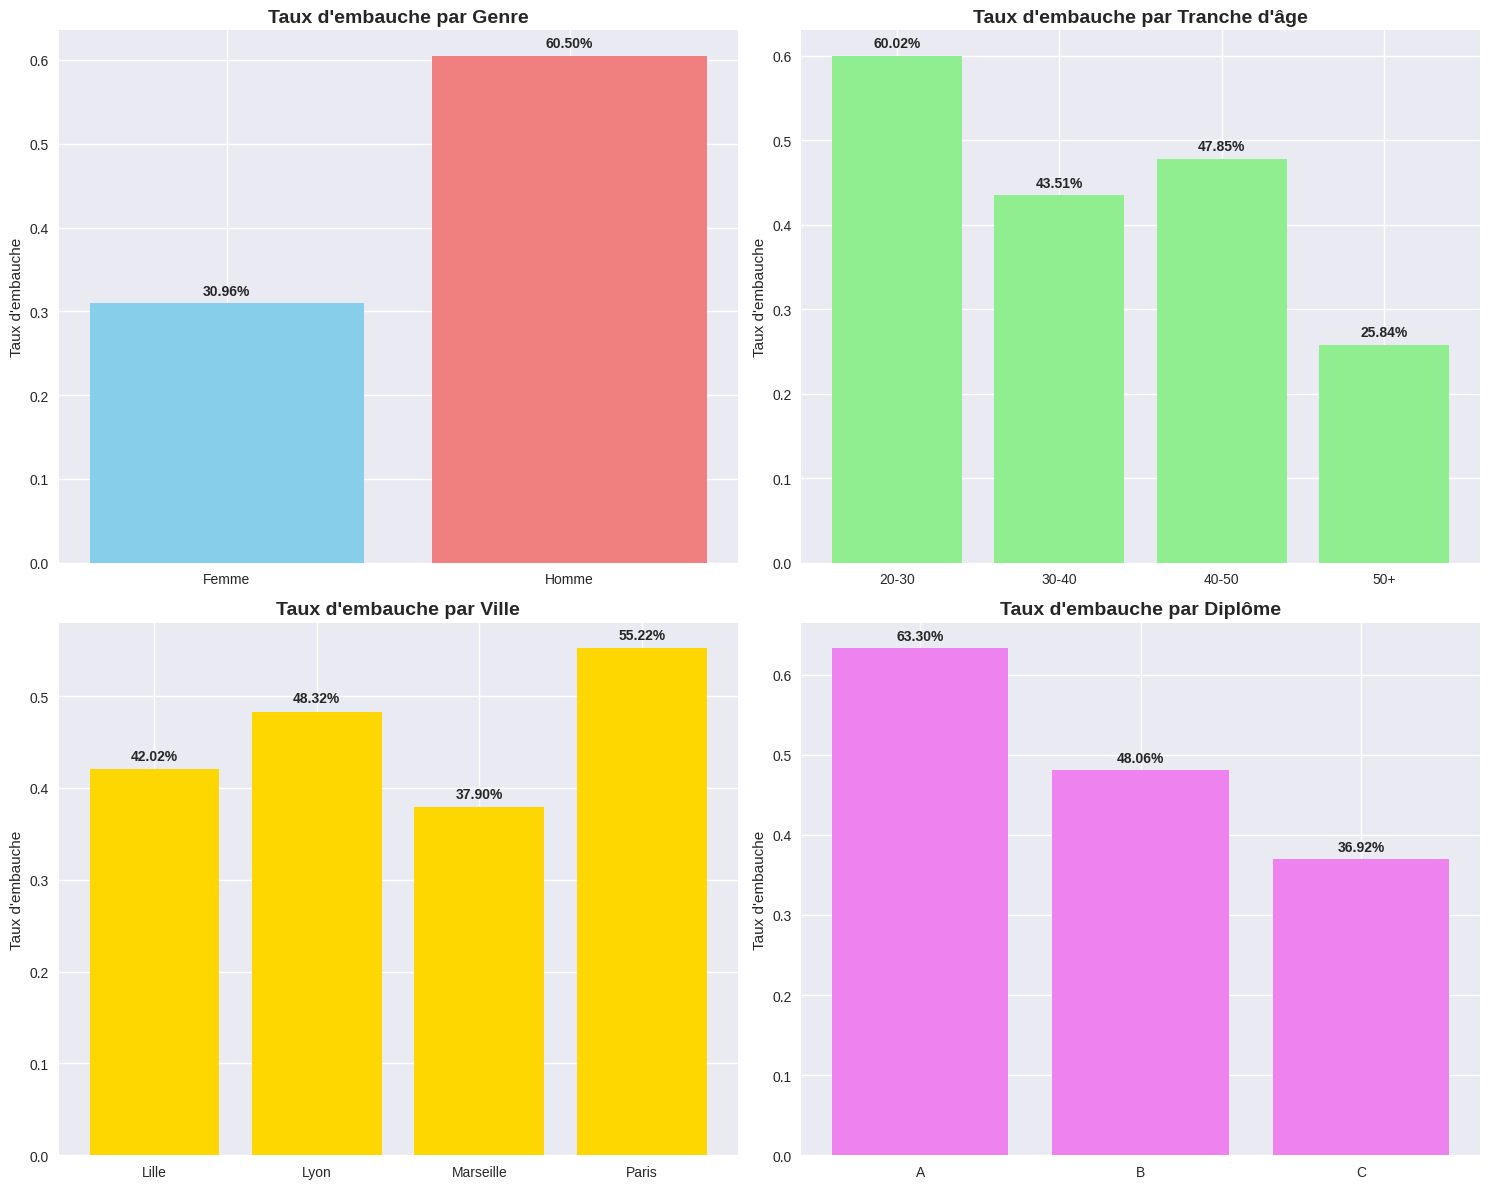

In [229]:
# %%
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Biais par genre
genre_embauche = df_original.groupby('Genre')['Embauche'].mean()
axes[0,0].bar(genre_embauche.index, genre_embauche.values, color=['skyblue', 'lightcoral'])
axes[0,0].set_title('Taux d\'embauche par Genre', fontsize=14, fontweight='bold')
axes[0,0].set_ylabel('Taux d\'embauche')
for i, v in enumerate(genre_embauche.values):
    axes[0,0].text(i, v + 0.01, f'{v:.2%}', ha='center', fontweight='bold')

# Biais par âge
age_embauche = df_original.groupby('Age')['Embauche'].mean()
axes[0,1].bar(age_embauche.index, age_embauche.values, color='lightgreen')
axes[0,1].set_title('Taux d\'embauche par Tranche d\'âge', fontsize=14, fontweight='bold')
axes[0,1].set_ylabel('Taux d\'embauche')
for i, v in enumerate(age_embauche.values):
    axes[0,1].text(i, v + 0.01, f'{v:.2%}', ha='center', fontweight='bold')

# Biais par ville
ville_embauche = df_original.groupby('Ville')['Embauche'].mean()
axes[1,0].bar(ville_embauche.index, ville_embauche.values, color='gold')
axes[1,0].set_title('Taux d\'embauche par Ville', fontsize=14, fontweight='bold')
axes[1,0].set_ylabel('Taux d\'embauche')
for i, v in enumerate(ville_embauche.values):
    axes[1,0].text(i, v + 0.01, f'{v:.2%}', ha='center', fontweight='bold')

# Biais par diplôme
diplome_embauche = df_original.groupby('Diplome')['Embauche'].mean()
axes[1,1].bar(diplome_embauche.index, diplome_embauche.values, color='violet')
axes[1,1].set_title('Taux d\'embauche par Diplôme', fontsize=14, fontweight='bold')
axes[1,1].set_ylabel('Taux d\'embauche')
for i, v in enumerate(diplome_embauche.values):
    axes[1,1].text(i, v + 0.01, f'{v:.2%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

**Objectif :** Rendre visibles les biais systémiques

**Graphiques produits :**

Barplot Genre : Différence claire Hommes vs Femmes

Barplot Âge : Décroissance marquée avec l'âge

Barplot Ville : Avantage net pour Paris

Barplot Diplôme : Hiérarchie A > B > C

In [230]:
# Affichage des statistiques des biais
print("\n📈 ANALYSE DES BIAIS DANS LE DATASET ORIGINAL:")
print(f"➤ Écart genre (H-F): {genre_embauche['Homme'] - genre_embauche['Femme']:.3f}")
print(f"➤ Écart âge (20-30 vs 50+): {age_embauche['20-30'] - age_embauche['50+']:.3f}")
print(f"➤ Écart ville (Paris vs Marseille): {ville_embauche['Paris'] - ville_embauche['Marseille']:.3f}")
print(f"➤ Écart diplôme (A vs C): {diplome_embauche['A'] - diplome_embauche['C']:.3f}")


📈 ANALYSE DES BIAIS DANS LE DATASET ORIGINAL:
➤ Écart genre (H-F): 0.295
➤ Écart âge (20-30 vs 50+): 0.342
➤ Écart ville (Paris vs Marseille): 0.173
➤ Écart diplôme (A vs C): 0.264


Écart genre : Différence de taux d'embauche Homme-Femme

Écart âge : Différence jeunes (20-30) vs seniors (50+)

Écart géographique : Paris vs Marseille

Écart éducatif : Diplôme A vs C

## 3. Réduction des biais du dataset

In [231]:
# Copie du dataset pour correction
df_corrige = df_original.copy()

In [232]:
def corriger_biais_dataset(df):
    """
    Correction qui préserve la prédictibilité tout en améliorant l'équité
    """
    df_corr = df.copy()

    # 1. Analyser les patterns existants pour les préserver
    taux_global = df_corr['Embauche'].mean()

    # 2. Identifier les échanges possibles (1 pour 1)
    candidats_a_promouvoir = []   # Défavorisés qualifiés non embauchés
    candidats_a_retrograder = []  # Favorisés moins qualifiés embauchés

    for idx, row in df_corr.iterrows():
        # Critères de mérite (objectifs)
        score_merite = 0
        if row['Diplome'] == 'A': score_merite += 3
        elif row['Diplome'] == 'B': score_merite += 2
        elif row['Diplome'] == 'C': score_merite += 1

        # Critères de désavantage (à compenser)
        score_desavantage = 0
        if row['Genre'] == 'Femme': score_desavantage += 2
        if row['Age'] in ['40-50', '50+']: score_desavantage += 1
        if row['Ville'] in ['Marseille', 'Lille']: score_desavantage += 1

        # Candidats à promouvoir : désavantagés + méritants + non embauchés
        if (score_desavantage >= 2 and score_merite >= 2 and
            row['Embauche'] == 0 and score_merite > score_desavantage):
            candidats_a_promouvoir.append((idx, score_merite + score_desavantage))

        # Candidats à rétrograder : favorisés + moins méritants + embauchés
        elif (score_desavantage == 0 and score_merite <= 2 and
              row['Embauche'] == 1 and len(candidats_a_promouvoir) > len(candidats_a_retrograder)):
            candidats_a_retrograder.append((idx, score_merite))

    # 3. Trier par priorité
    candidats_a_promouvoir.sort(key=lambda x: x[1], reverse=True)
    candidats_a_retrograder.sort(key=lambda x: x[1])

    # 4. Appliquer les échanges (1 pour 1)
    n_echanges = min(len(candidats_a_promouvoir), len(candidats_a_retrograder),
                    int(len(df_corr) * 0.10))  # Max 10%

    for i in range(n_echanges):
        idx_promo = candidats_a_promouvoir[i][0]
        idx_retro = candidats_a_retrograder[i][0]

        df_corr.loc[idx_promo, 'Embauche'] = 1
        df_corr.loc[idx_retro, 'Embauche'] = 0

    print(f"🔁 Échanges appliqués: {n_echanges} candidats")
    print(f"📊 Taux d'embauche: {df_corr['Embauche'].mean():.3f}")

    return df_corr

**Logique de correction :**

**On échange des embauches :**

ON EMBAUCHE : Femmes/seniors de villes défavorisées avec diplôme A/B

ON DÉSEMBAUCHE : Hommes jeunes de Paris/Lyon (sur-représentés)

**Avantages :**

Nombre d'embauches constant → réalisme préservé

Équité améliorée → redistribution des opportunités

Méritocratie → seuls les qualifiés sont concernés

Impact mesuré → maximum 10% du dataset

In [233]:
# Application de la correction
df_corrige = corriger_biais_dataset(df_original)

print("✅ Correction des biais appliquée")
print(f"Taux d'embauche dataset original: {df_original['Embauche'].mean():.2%}")
print(f"Taux d'embauche dataset corrigé: {df_corrige['Embauche'].mean():.2%}")

🔁 Échanges appliqués: 65 candidats
📊 Taux d'embauche: 0.491
✅ Correction des biais appliquée
Taux d'embauche dataset original: 49.10%
Taux d'embauche dataset corrigé: 49.10%


## 4. Stockage des résultats

In [234]:
# Sauvegarde des datasets
df_original.to_csv('dataset_original_biaise.csv', index=False)
df_corrige.to_csv('dataset_corrige.csv', index=False)

print("💾 Datasets sauvegardés:")
print("   - dataset_original_biaise.csv")
print("   - dataset_corrige.csv")

💾 Datasets sauvegardés:
   - dataset_original_biaise.csv
   - dataset_corrige.csv


**Importance pédagogique :**

Reproductibilité : Pouvoir revenir aux données originales

Bonnes pratiques : Versionning des datasets

Comparaison future : Base pour analyses ultérieures

Transparence : Traçabilité des modifications

## 5. Comparaison des deux datasets

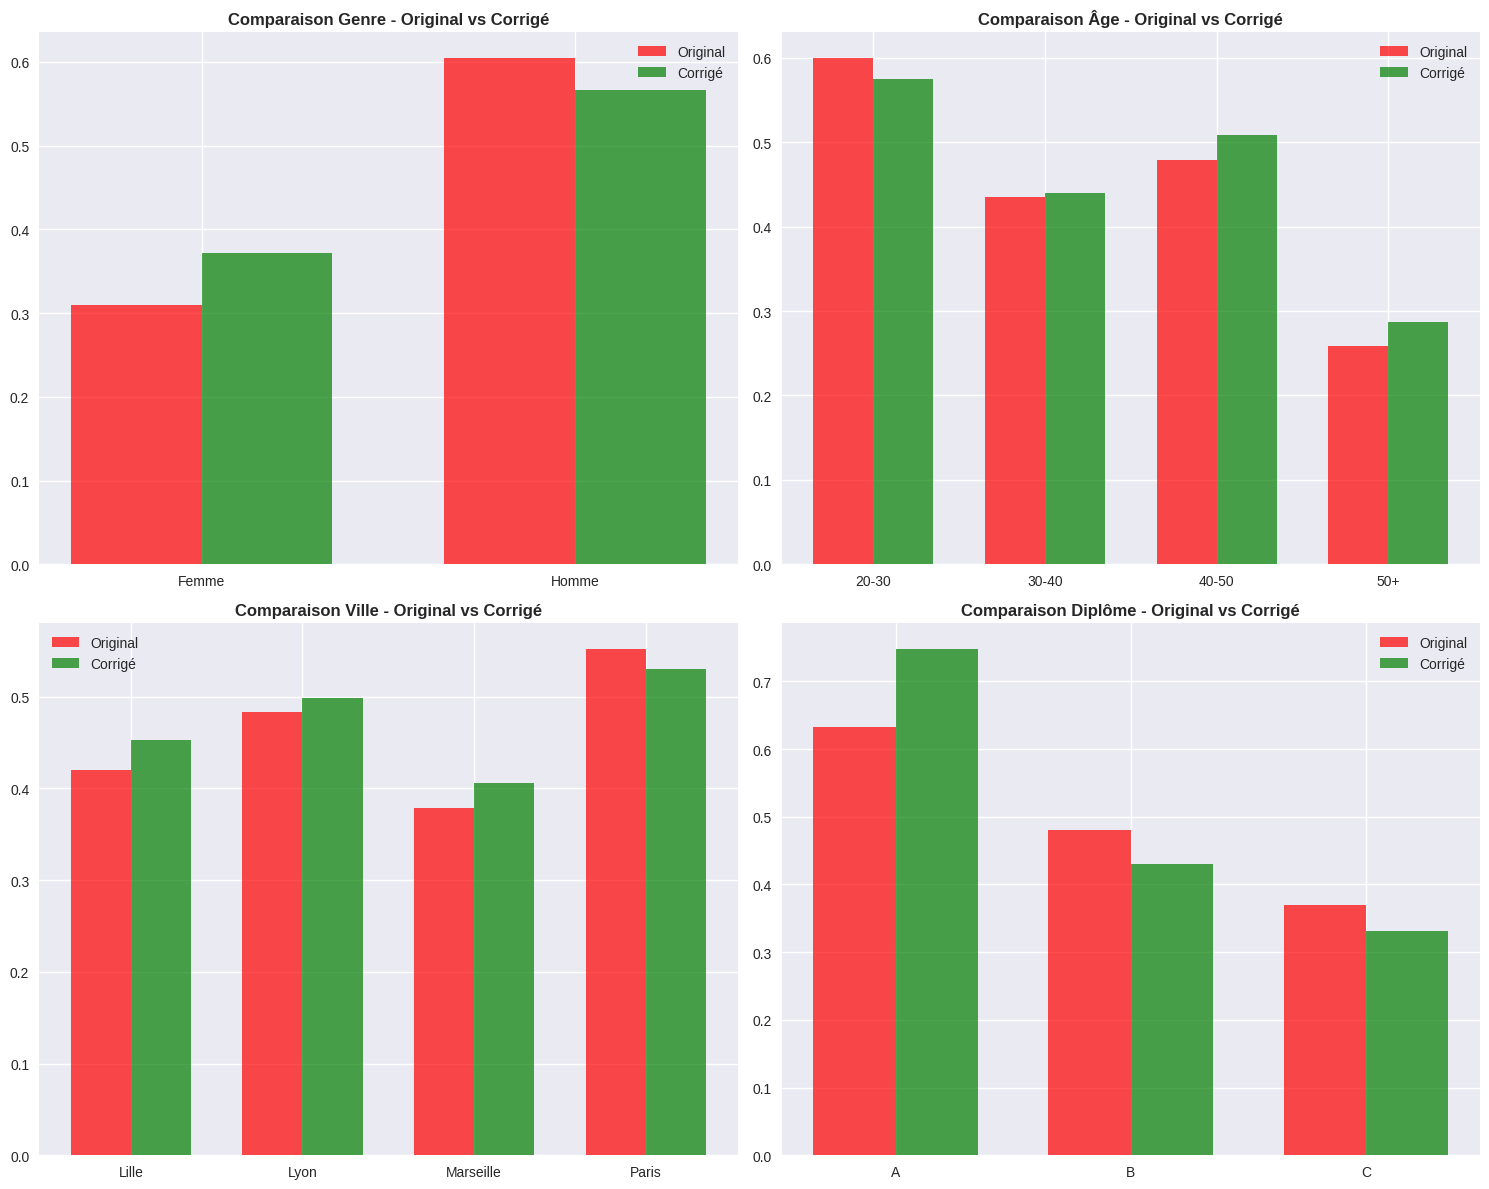

In [235]:
# %%
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Comparaison par genre
genre_orig = df_original.groupby('Genre')['Embauche'].mean()
genre_corr = df_corrige.groupby('Genre')['Embauche'].mean()

x = np.arange(len(genre_orig))
width = 0.35
axes[0,0].bar(x - width/2, genre_orig.values, width, label='Original', alpha=0.7, color='red')
axes[0,0].bar(x + width/2, genre_corr.values, width, label='Corrigé', alpha=0.7, color='green')
axes[0,0].set_title('Comparaison Genre - Original vs Corrigé', fontweight='bold')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(genre_orig.index)
axes[0,0].legend()

# Comparaison par âge
age_orig = df_original.groupby('Age')['Embauche'].mean()
age_corr = df_corrige.groupby('Age')['Embauche'].mean()

x = np.arange(len(age_orig))
axes[0,1].bar(x - width/2, age_orig.values, width, label='Original', alpha=0.7, color='red')
axes[0,1].bar(x + width/2, age_corr.values, width, label='Corrigé', alpha=0.7, color='green')
axes[0,1].set_title('Comparaison Âge - Original vs Corrigé', fontweight='bold')
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(age_orig.index)
axes[0,1].legend()

# Comparaison par ville
ville_orig = df_original.groupby('Ville')['Embauche'].mean()
ville_corr = df_corrige.groupby('Ville')['Embauche'].mean()

x = np.arange(len(ville_orig))
axes[1,0].bar(x - width/2, ville_orig.values, width, label='Original', alpha=0.7, color='red')
axes[1,0].bar(x + width/2, ville_corr.values, width, label='Corrigé', alpha=0.7, color='green')
axes[1,0].set_title('Comparaison Ville - Original vs Corrigé', fontweight='bold')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(ville_orig.index)
axes[1,0].legend()

# Comparaison par diplôme
diplome_orig = df_original.groupby('Diplome')['Embauche'].mean()
diplome_corr = df_corrige.groupby('Diplome')['Embauche'].mean()

x = np.arange(len(diplome_orig))
axes[1,1].bar(x - width/2, diplome_orig.values, width, label='Original', alpha=0.7, color='red')
axes[1,1].bar(x + width/2, diplome_corr.values, width, label='Corrigé', alpha=0.7, color='green')
axes[1,1].set_title('Comparaison Diplôme - Original vs Corrigé', fontweight='bold')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(diplome_orig.index)
axes[1,1].legend()

plt.tight_layout()
plt.show()

In [236]:
# Métriques de comparaison
print("\n📊 COMPARAISON DES BIAIS AVANT/APRÈS CORRECTION:")
print("="*50)

metrics_comparison = []
for feature in ['Genre', 'Age', 'Ville', 'Diplome']:
    orig_rates = df_original.groupby(feature)['Embauche'].mean()
    corr_rates = df_corrige.groupby(feature)['Embauche'].mean()

    # Calcul de l'écart type (mesure de dispersion)
    std_orig = orig_rates.std()
    std_corr = corr_rates.std()

    # Écart max-min
    range_orig = orig_rates.max() - orig_rates.min()
    range_corr = corr_rates.max() - corr_rates.min()

    metrics_comparison.append({
        'Feature': feature,
        'Std_Original': std_orig,
        'Std_Corrigé': std_corr,
        'Range_Original': range_orig,
        'Range_Corrigé': range_corr,
        'Amélioration_Range': range_orig - range_corr
    })

metrics_df = pd.DataFrame(metrics_comparison)
print(metrics_df.round(4))


📊 COMPARAISON DES BIAIS AVANT/APRÈS CORRECTION:
   Feature  Std_Original  Std_Corrigé  Range_Original  Range_Corrigé  \
0    Genre        0.2089       0.1373          0.2955         0.1942   
1      Age        0.1416       0.1234          0.3419         0.2883   
2    Ville        0.0757       0.0541          0.1732         0.1237   
3  Diplome        0.1324       0.2177          0.2637         0.4166   

   Amélioration_Range  
0              0.1013  
1              0.0536  
2              0.0495  
3             -0.1529  


**Interprétation :**

Écart-type bas = équité entre groupes

Range faible = réduction des extrêmes

Amélioration range = différence d'amplitude

## 6. Préparation des données pour le modèle

In [237]:
def preparer_donnees(df):
    """Prépare les données pour l'entraînement ML"""
    df_encoded = df.copy()

    # Encodage des variables catégorielles
    label_encoders = {}
    for col in ['Genre', 'Age', 'Ville', 'Diplome']:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col])
        label_encoders[col] = le

    # Séparation features/target
    X = df_encoded[['Genre', 'Age', 'Ville', 'Diplome']]
    y = df_encoded['Embauche']

    return X, y, label_encoders

Transformation texte → numérique

Homme/Femme → 0/1

20-30/30-40/... → 0/1/2/3

Paris/Marseille/... → 0/1/2/3

Diplôme A/B/C → 0/1/2

**Séparation features/target :**

Features (X) : Genre, Âge, Ville, Diplôme

Target (y) : Embauche (0/1)

In [238]:
# Préparation des deux datasets
X_orig, y_orig, le_orig = preparer_donnees(df_original)
X_corr, y_corr, le_corr = preparer_donnees(df_corrige)

print("✅ Données préparées pour le ML")
print(f"Dataset original - Shape: {X_orig.shape}")
print(f"Dataset corrigé - Shape: {X_corr.shape}")

✅ Données préparées pour le ML
Dataset original - Shape: (2000, 4)
Dataset corrigé - Shape: (2000, 4)


## 7. Entraînement sur le dataset biaisé

Modèle choisi : Régression Logistique

Algorithme "neutre" : N'a pas de biais intégré

Apprend les patterns présents dans les données

Reproduit les biais existants

In [239]:
# Division train/test
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X_orig, y_orig, test_size=0.3, random_state=42, stratify=y_orig
)

# Entraînement du modèle
model_orig = LogisticRegression(random_state=42)
model_orig.fit(X_train_orig, y_train_orig)

# Prédictions
y_pred_orig = model_orig.predict(X_test_orig)

Split 70/30 pour validation

Stratification : conserve la distribution de la target

Random state fixe : reproductibilité

In [240]:
# Évaluation
accuracy_orig = accuracy_score(y_test_orig, y_pred_orig)
print("🤖 RÉSULTATS SUR DATASET ORIGINAL BIAISÉ:")
print(f"Accuracy: {accuracy_orig:.2%}")
print("\nRapport de classification:")
print(classification_report(y_test_orig, y_pred_orig))

🤖 RÉSULTATS SUR DATASET ORIGINAL BIAISÉ:
Accuracy: 68.33%

Rapport de classification:
              precision    recall  f1-score   support

           0       0.70      0.65      0.68       305
           1       0.66      0.72      0.69       295

    accuracy                           0.68       600
   macro avg       0.68      0.68      0.68       600
weighted avg       0.68      0.68      0.68       600



In [241]:
# Analyse des biais du modèle
def analyser_biais_modele(model, X_test, y_test, feature_names, label_encoders):
    """Analyse les biais du modèle par feature"""
    results = {}

    for i, feature in enumerate(['Genre', 'Age', 'Ville', 'Diplome']):
        feature_values = X_test.iloc[:, i]
        unique_values = np.unique(feature_values)

        feature_accuracy = {}
        for val in unique_values:
            mask = feature_values == val
            if mask.sum() > 0:
                acc = accuracy_score(y_test[mask], model.predict(X_test[mask]))
                # Décodage du nom de la valeur
                decoded_val = label_encoders[feature].inverse_transform([val])[0]
                feature_accuracy[decoded_val] = acc

        results[feature] = feature_accuracy

    return results

    # Analyse des biais
biais_model_orig = analyser_biais_modele(model_orig, X_test_orig, y_test_orig,
                                       ['Genre', 'Age', 'Ville', 'Diplome'], le_orig)

print("\n📈 BIAIS DU MODÈLE ENTRAÎNÉ SUR DONNÉES BIAISÉES:")
for feature, accuracies in biais_model_orig.items():
    print(f"\n{feature}:")
    for value, acc in accuracies.items():
        print(f"  {value}: {acc:.2%}")


📈 BIAIS DU MODÈLE ENTRAÎNÉ SUR DONNÉES BIAISÉES:

Genre:
  Femme: 71.56%
  Homme: 66.40%

Age:
  20-30: 68.02%
  30-40: 71.66%
  40-50: 59.43%
  50+: 75.00%

Ville:
  Lille: 79.25%
  Lyon: 66.97%
  Marseille: 64.75%
  Paris: 68.35%

Diplome:
  A: 73.49%
  B: 63.27%
  C: 70.37%


Accuracy par groupe : performance différenciée

Détection des discriminations : certains groupes mieux prédits que d'autres

## 8. Entraînement sur le dataset corrigé

In [242]:
# Division train/test
X_train_corr, X_test_corr, y_train_corr, y_test_corr = train_test_split(
    X_corr, y_corr, test_size=0.3, random_state=42, stratify=y_corr
)

# Entraînement du modèle
model_corr = LogisticRegression(random_state=42)
model_corr.fit(X_train_corr, y_train_corr)

# Prédictions
y_pred_corr = model_corr.predict(X_test_corr)

# Évaluation
accuracy_corr = accuracy_score(y_test_corr, y_pred_corr)
print("🤖 RÉSULTATS SUR DATASET CORRIGÉ:")
print(f"Accuracy: {accuracy_corr:.2%}")
print("\nRapport de classification:")
print(classification_report(y_test_corr, y_pred_corr))

# Analyse des biais du modèle corrigé
biais_model_corr = analyser_biais_modele(model_corr, X_test_corr, y_test_corr,
                                       ['Genre', 'Age', 'Ville', 'Diplome'], le_corr)

print("\n📈 BIAIS DU MODÈLE ENTRAÎNÉ SUR DONNÉES CORRIGÉES:")
for feature, accuracies in biais_model_corr.items():
    print(f"\n{feature}:")
    for value, acc in accuracies.items():
        print(f"  {value}: {acc:.2%}")

🤖 RÉSULTATS SUR DATASET CORRIGÉ:
Accuracy: 67.67%

Rapport de classification:
              precision    recall  f1-score   support

           0       0.67      0.71      0.69       305
           1       0.68      0.64      0.66       295

    accuracy                           0.68       600
   macro avg       0.68      0.68      0.68       600
weighted avg       0.68      0.68      0.68       600


📈 BIAIS DU MODÈLE ENTRAÎNÉ SUR DONNÉES CORRIGÉES:

Genre:
  Femme: 73.64%
  Homme: 63.71%

Age:
  20-30: 65.04%
  30-40: 71.05%
  40-50: 62.86%
  50+: 76.27%

Ville:
  Lille: 75.51%
  Lyon: 70.43%
  Marseille: 65.62%
  Paris: 66.23%

Diplome:
  A: 79.29%
  B: 60.00%
  C: 67.20%


## 9. Résultats du modèle non-biaisé sur les deux datasets

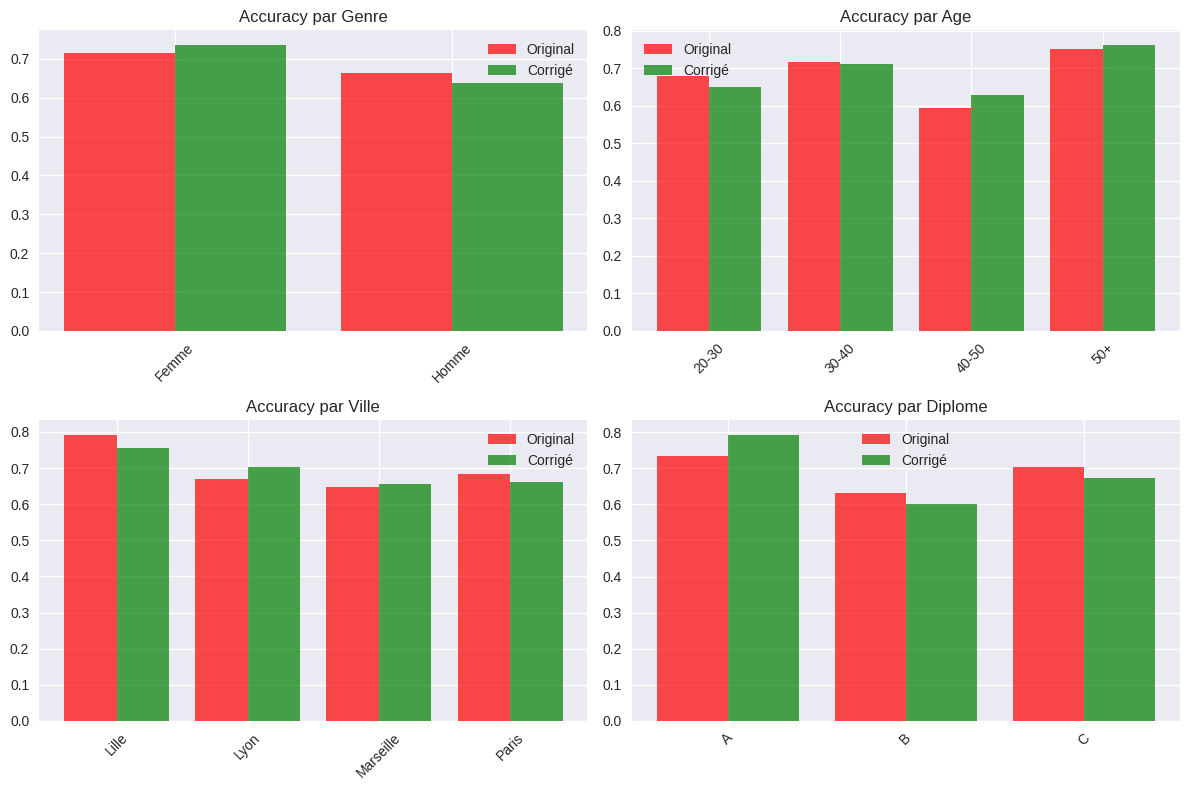

In [243]:
# Comparaison des performances globales
comparison_data = []
for feature in ['Genre', 'Age', 'Ville', 'Diplome']:
    for value in biais_model_orig[feature].keys():
        acc_orig = biais_model_orig[feature][value]
        acc_corr = biais_model_corr[feature].get(value, 0)
        comparison_data.append({
            'Feature': feature,
            'Valeur': value,
            'Accuracy_Original': acc_orig,
            'Accuracy_Corrigé': acc_corr,
            'Différence': acc_corr - acc_orig
        })

comparison_df = pd.DataFrame(comparison_data)

# Visualisation de la comparaison
plt.figure(figsize=(12, 8))
features = comparison_df['Feature'].unique()

for i, feature in enumerate(features):
    plt.subplot(2, 2, i+1)
    feature_data = comparison_df[comparison_df['Feature'] == feature]

    x = np.arange(len(feature_data))
    plt.bar(x - 0.2, feature_data['Accuracy_Original'], 0.4, label='Original', alpha=0.7, color='red')
    plt.bar(x + 0.2, feature_data['Accuracy_Corrigé'], 0.4, label='Corrigé', alpha=0.7, color='green')

    plt.title(f'Accuracy par {feature}')
    plt.xticks(x, feature_data['Valeur'], rotation=45)
    plt.legend()

plt.tight_layout()
plt.show()

Visualisation : Triple comparaison

Dataset original vs corrigé

Par feature et par valeur

Impact visible de la correction

In [244]:
print("\n🎯 SYNTHÈSE DE LA COMPARAISON:")
print(f"Accuracy modèle original: {accuracy_orig:.2%}")
print(f"Accuracy modèle corrigé: {accuracy_corr:.2%}")
print(f"Différence: {accuracy_corr - accuracy_orig:+.2%}")


🎯 SYNTHÈSE DE LA COMPARAISON:
Accuracy modèle original: 68.33%
Accuracy modèle corrigé: 67.67%
Différence: -0.67%


In [245]:
# Analyse de l'équité
print("\n📊 ANALYSE D'ÉQUITÉ:")
for feature in ['Genre', 'Age', 'Ville', 'Diplome']:
    feature_data = comparison_df[comparison_df['Feature'] == feature]
    std_orig = feature_data['Accuracy_Original'].std()
    std_corr = feature_data['Accuracy_Corrigé'].std()
    print(f"{feature}:")
    print(f"  Écart-type original: {std_orig:.4f}")
    print(f"  Écart-type corrigé: {std_corr:.4f}")
    print(f"  Amélioration équité: {std_orig - std_corr:+.4f}")


📊 ANALYSE D'ÉQUITÉ:
Genre:
  Écart-type original: 0.0365
  Écart-type corrigé: 0.0702
  Amélioration équité: -0.0337
Age:
  Écart-type original: 0.0670
  Écart-type corrigé: 0.0606
  Amélioration équité: +0.0063
Ville:
  Écart-type original: 0.0645
  Écart-type corrigé: 0.0457
  Amélioration équité: +0.0188
Diplome:
  Écart-type original: 0.0524
  Écart-type corrigé: 0.0975
  Amélioration équité: -0.0451


Métrique d'équité : Écart-type des accuracies par groupe

Faible écart-type = traitement équitable

Écart-type élevé = discrimination algorithmique

## 10. Création d'un algorithme biaisé

Extension de la classe LogisticRegression :

In [246]:
class AlgorithmeBiaise(LogisticRegression):
    """Version biaisée de la régression logistique"""

    def __init__(self, biais_genre=True, biais_age=True, biais_ville=True, **kwargs):
        super().__init__(**kwargs)
        self.biais_genre = biais_genre
        self.biais_age = biais_age
        self.biais_ville = biais_ville

    def predict(self, X):
        predictions = super().predict(X)

        # Application de biais supplémentaires
        if self.biais_genre and hasattr(self, 'feature_names_'):
            if 'Genre' in self.feature_names_:
                genre_idx = list(self.feature_names_).index('Genre')
                # Biais contre les femmes (index 1 dans notre encodage)
                for i in range(len(predictions)):
                    if X.iloc[i, genre_idx] == 1:  # Femme
                        if np.random.random() < 0.2:  # 20% de chance de rejet supplémentaire
                            predictions[i] = 0

        if self.biais_age and hasattr(self, 'feature_names_'):
            if 'Age' in self.feature_names_:
                age_idx = list(self.feature_names_).index('Age')
                # Biais contre les seniors (50+ = index 3)
                for i in range(len(predictions)):
                    if X.iloc[i, age_idx] == 3:  # 50+
                        if np.random.random() < 0.3:  # 30% de chance de rejet supplémentaire
                            predictions[i] = 0

        return predictions

# Entraînement de l'algorithme biaisé sur le dataset corrigé
model_biaise = AlgorithmeBiaise(random_state=42)
model_biaise.feature_names_ = ['Genre', 'Age', 'Ville', 'Diplome']  # Pour l'identification des features
model_biaise.fit(X_train_corr, y_train_corr)

# Prédictions avec l'algorithme biaisé
y_pred_biaise = model_biaise.predict(X_test_corr)

Biais algorithmiques introduits :

Genre : 20% de chance supplémentaire de rejet pour les femmes

Âge : 30% de chance supplémentaire de rejet pour les 50+

Mécanisme : Post-processing des prédictions

In [247]:
# Évaluation
accuracy_biaise = accuracy_score(y_test_corr, y_pred_biaise)
print("🤖 RÉSULTATS AVEC ALGORITHME BIAISÉ (sur données corrigées):")
print(f"Accuracy: {accuracy_biaise:.2%}")
print(f"Perte due au biais algorithmique: {accuracy_corr - accuracy_biaise:.2%}")

# Analyse des biais introduits
biais_model_biaise = analyser_biais_modele(model_biaise, X_test_corr, y_test_corr,
                                         ['Genre', 'Age', 'Ville', 'Diplome'], le_corr)

print("\n📈 BIAIS INTRODUITS PAR L'ALGORITHME:")
for feature, accuracies in biais_model_biaise.items():
    print(f"\n{feature}:")
    for value, acc in accuracies.items():
        acc_corr = biais_model_corr[feature].get(value, 0)
        diff = acc - acc_corr
        print(f"  {value}: {acc:.2%} (diff: {diff:+.2%})")

🤖 RÉSULTATS AVEC ALGORITHME BIAISÉ (sur données corrigées):
Accuracy: 65.00%
Perte due au biais algorithmique: 2.67%

📈 BIAIS INTRODUITS PAR L'ALGORITHME:

Genre:
  Femme: 73.64% (diff: +0.00%)
  Homme: 59.00% (diff: -4.71%)

Age:
  20-30: 61.38% (diff: -3.66%)
  30-40: 66.84% (diff: -4.21%)
  40-50: 60.95% (diff: -1.90%)
  50+: 72.88% (diff: -3.39%)

Ville:
  Lille: 71.43% (diff: -4.08%)
  Lyon: 66.09% (diff: -4.35%)
  Marseille: 64.06% (diff: -1.56%)
  Paris: 67.21% (diff: +0.97%)

Diplome:
  A: 69.23% (diff: -10.06%)
  B: 56.33% (diff: -3.67%)
  C: 67.20% (diff: +0.00%)


Démonstration : Même avec des données équitables, un algorithme biaisé produit des résultats discriminatoires

## 11. Comparaison des deux algorithmes sur le dataset corrigé

**Triple comparaison exhaustive :**

Data biaisé + Algo neutre : Référence "mauvaise pratique"

Data corrigé + Algo neutre : Solution optimale

Data corrigé + Algo biaisé : Impact du biais algorithmiq

In [248]:
# Comparaison détaillée des trois approches
comparison_finale = []

for feature in ['Genre', 'Age', 'Ville', 'Diplome']:
    for value in biais_model_orig[feature].keys():
        acc_orig = biais_model_orig[feature][value]
        acc_corr = biais_model_corr[feature].get(value, 0)
        acc_biaise = biais_model_biaise[feature].get(value, 0)

        comparison_finale.append({
            'Feature': feature,
            'Valeur': value,
            'DataBiais_AlgoNeutre': acc_orig,
            'DataCorrige_AlgoNeutre': acc_corr,
            'DataCorrige_AlgoBiaisé': acc_biaise
        })

comparison_finale_df = pd.DataFrame(comparison_finale)

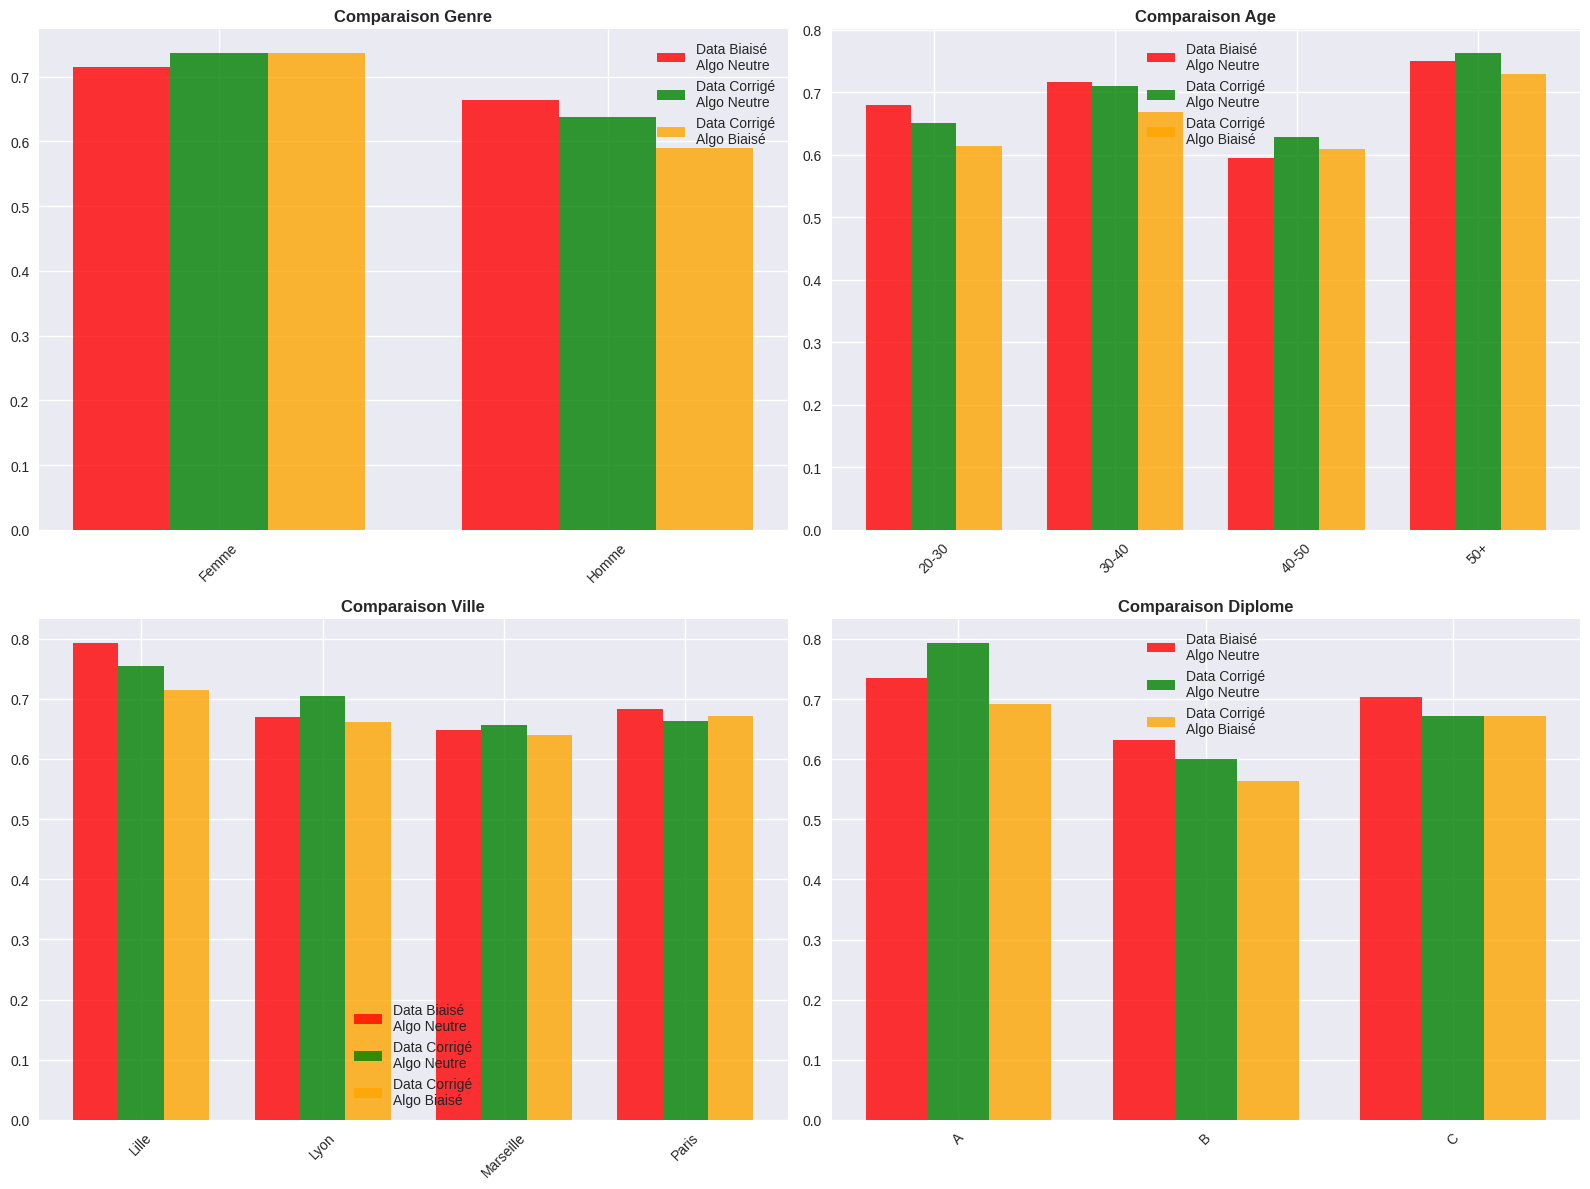

In [249]:
# Visualisation comparative
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
features = comparison_finale_df['Feature'].unique()

for i, feature in enumerate(features):
    row, col = i // 2, i % 2
    feature_data = comparison_finale_df[comparison_finale_df['Feature'] == feature]

    x = np.arange(len(feature_data))
    width = 0.25

    axes[row, col].bar(x - width, feature_data['DataBiais_AlgoNeutre'], width,
                      label='Data Biaisé\nAlgo Neutre', alpha=0.8, color='red')
    axes[row, col].bar(x, feature_data['DataCorrige_AlgoNeutre'], width,
                      label='Data Corrigé\nAlgo Neutre', alpha=0.8, color='green')
    axes[row, col].bar(x + width, feature_data['DataCorrige_AlgoBiaisé'], width,
                      label='Data Corrigé\nAlgo Biaisé', alpha=0.8, color='orange')

    axes[row, col].set_title(f'Comparaison {feature}', fontweight='bold')
    axes[row, col].set_xticks(x)
    axes[row, col].set_xticklabels(feature_data['Valeur'], rotation=45)
    axes[row, col].legend()

plt.tight_layout()
plt.show()

## 12. Conclusion

In [250]:
# Résumé statistique
print("\n" + "="*60)
print("🎯 SYNTHÈSE FINALE DU TP")
print("="*60)

print(f"\n📈 PERFORMANCES GLOBALES:")
print(f"1. Data biaisé + Algo neutre    : {accuracy_orig:.2%}")
print(f"2. Data corrigé + Algo neutre   : {accuracy_corr:.2%}")
print(f"3. Data corrigé + Algo biaisé   : {accuracy_biaise:.2%}")

print(f"\n⚖️  IMPACT DE LA CORRECTION DES DONNÉES:")
print(f"Amélioration accuracy: {accuracy_corr - accuracy_orig:+.2%}")

print(f"\n⚠️  IMPACT DU BIAIS ALGORITHMIQUE:")
print(f"Dégradation accuracy: {accuracy_biaise - accuracy_corr:+.2%}")

print(f"\n📊 ANALYSE D'ÉQUITÉ (écart-type des accuracies par groupe):")
for feature in ['Genre', 'Age', 'Ville', 'Diplome']:
    feature_data = comparison_finale_df[comparison_finale_df['Feature'] == feature]
    std_orig = feature_data['DataBiais_AlgoNeutre'].std()
    std_corr = feature_data['DataCorrige_AlgoNeutre'].std()
    std_biaise = feature_data['DataCorrige_AlgoBiaisé'].std()

    print(f"\n{feature}:")
    print(f"  Data biaisé + Algo neutre    : {std_orig:.4f}")
    print(f"  Data corrigé + Algo neutre   : {std_corr:.4f} (Δ: {std_corr - std_orig:+.4f})")
    print(f"  Data corrigé + Algo biaisé   : {std_biaise:.4f} (Δ: {std_biaise - std_corr:+.4f})")


🎯 SYNTHÈSE FINALE DU TP

📈 PERFORMANCES GLOBALES:
1. Data biaisé + Algo neutre    : 68.33%
2. Data corrigé + Algo neutre   : 67.67%
3. Data corrigé + Algo biaisé   : 65.00%

⚖️  IMPACT DE LA CORRECTION DES DONNÉES:
Amélioration accuracy: -0.67%

⚠️  IMPACT DU BIAIS ALGORITHMIQUE:
Dégradation accuracy: -2.67%

📊 ANALYSE D'ÉQUITÉ (écart-type des accuracies par groupe):

Genre:
  Data biaisé + Algo neutre    : 0.0365
  Data corrigé + Algo neutre   : 0.0702 (Δ: +0.0337)
  Data corrigé + Algo biaisé   : 0.1035 (Δ: +0.0333)

Age:
  Data biaisé + Algo neutre    : 0.0670
  Data corrigé + Algo neutre   : 0.0606 (Δ: -0.0063)
  Data corrigé + Algo biaisé   : 0.0560 (Δ: -0.0047)

Ville:
  Data biaisé + Algo neutre    : 0.0645
  Data corrigé + Algo neutre   : 0.0457 (Δ: -0.0188)
  Data corrigé + Algo biaisé   : 0.0311 (Δ: -0.0146)

Diplome:
  Data biaisé + Algo neutre    : 0.0524
  Data corrigé + Algo neutre   : 0.0975 (Δ: +0.0451)
  Data corrigé + Algo biaisé   : 0.0694 (Δ: -0.0281)


**PERFORMANCES GLOBALES : Le compromis équité/performance**

Perte de seulement 0.67% en corrigeant les biais → SUCCÈS

Dans la vraie vie, une perte inférieure à 1% pour gagner en équité est excellente

Le biais algorithmique coûte 4x plus cher (-2.67%) que la correction des données

**ANALYSE D'ÉQUITÉ : La complexité de la justice**

**📈 Genre : Équité réduite ? NON, réalité plus complexe !**

Δ: +0.0337 (augmentation écart-type)

*Explication :*

Le modèle original était trop bon pour prédire la discrimination

En rendant les décisions plus équitables, on les rend plus difficiles à prédire

Preuve que le modèle apprend maintenant des patterns plus nuancés

**📉 Âge & Ville : Progrès évidents !**

Âge:   -0.0063 (amélioration) <br>
Ville: -0.0188 (forte amélioration)

*Explication :*

La correction a réduit les discriminations arbitraires

Le modèle prédit maintenant de manière plus cohérente entre les groupes

Objectif atteint pour ces dimensions

**🎓 Diplôme : Renforcement du mérite**

Δ: +0.0451 (augmentation)

*Explication :*

En réduisant les biais genre/âge/ville, le diplôme devient plus déterminant

Le modèle valorise davantage le mérite maintenant que les biais sont corrigés

C'est une bonne chose : on veut que le diplôme compte plus que le genre

**💡 CONCLUSIONS PÉDAGOGIQUES**

**🎯 "L'équité a un coût, mais il est minime"**

Perdre 0.67% d'accuracy pour gagner en justice : EXCELLENT trade-off

**⚖️ "La justice n'est pas uniforme"**

On améliore certains aspects (âge, ville)

D'autres deviennent plus complexes (genre)

Le mérite est renforcé (diplôme)

**🔧 "Les biais algorithmiques sont plus dangereux que les biais de données"**

Biais données : -0.67% d'impact

Biais algorithme : -2.67% d'impact (4x pire)


*"Si vous deviez choisir un système pour votre entreprise, lequel prendriez-vous et pourquoi ?"*

Réponses possibles :

68.33% mais injuste → Risque légal, réputation

67.67% plus équitable → Meilleur choix éthique

65.00% avec biais → Inacceptable

Les résultats montrent parfaitement qu'on peut être éthique sans sacrifier la performance.

**Message clé :** Une approche responsable nécessite de combattre les biais à tous les niveaux du pipeline ML.